# Model ARIMA — Forecasting Harga Saham Batubara IDX

Notebook ini membangun model **ARIMA (AutoRegressive Integrated Moving Average)** sebagai
komponen linear dari framework Hybrid ARIMA-LSTM.

Tahapan:
1. Load data & konfigurasi
2. Grid search orde optimal (p, d, q) per emiten via AIC/BIC
3. Training & fitting ARIMA terbaik
4. Diagnostik residual (Ljung-Box, Jarque-Bera, Q-Q Plot)
5. In-sample forecast vs aktual
6. Out-of-sample forecast (test set)
7. Evaluasi metrik: MAE, RMSE, MAPE, R²
8. Export residual → input LSTM (Notebook 03)
9. Tabel perbandingan model & visualisasi jurnal

Output utama:
- `data/arima_residuals.pkl`  — residual per emiten (feed ke LSTM)
- `data/arima_fitted.pkl`     — fitted values per emiten
- `data/arima_forecast.pkl`   — forecast test set per emiten
- `figures/fig07_*.png` s.d. `fig13_*.png`
- `data/tabel03_arima_orders.csv`
- `data/tabel04_arima_metrics.csv`


## 1. Import Library

In [6]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
# matplotlib.use("Agg")   # aktifkan jika run sebagai script .py
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from scipy import stats
from scipy.stats import jarque_bera, shapiro
import itertools
import pickle
import os

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf as sm_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
%matplotlib inline

## 2. Konfigurasi Visualisasi (konsisten dengan Notebook EDA)

In [8]:
FONT = "DejaVu Serif"

plt.rcParams.update({
    "font.family":        FONT,
    "font.size":          10,
    "axes.titlesize":     11,
    "axes.labelsize":     10,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "legend.fontsize":    9,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.05,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.25,
    "grid.linestyle":     "--",
    "grid.linewidth":     0.6,
})

C = {
    "navy":   "#1B3A6B",
    "blue":   "#2471A3",
    "red":    "#C0392B",
    "orange": "#D35400",
    "green":  "#1E8449",
    "gray":   "#7F8C8D",
    "lblue":  "#AED6F1",
    "lred":   "#F5B7B1",
    "lgreen": "#A9DFBF",
}

DIR_FIG  = "figures"
DIR_DATA = "data"
os.makedirs(DIR_FIG,  exist_ok=True)
os.makedirs(DIR_DATA, exist_ok=True)

ticker_list = ["ADRO", "PTBA", "INDY", "ITMG"]
warna_saham = [C["navy"], C["blue"], C["green"], C["red"]]

## 3. Load Dataset

In [9]:
df = pd.read_csv(
    "harga_saham_batubara.csv",
    index_col=0,
    parse_dates=True
)

print("Shape  :", df.shape)
print("Period :", df.index[0].date(), "→", df.index[-1].date())
print("Columns:", df.columns.tolist())
df[ticker_list].tail(3)

Shape  : (2869, 8)
Period : 2014-01-02 → 2024-12-31
Columns: ['ADRO', 'PTBA', 'INDY', 'ITMG', 'ret_ADRO', 'ret_PTBA', 'ret_INDY', 'ret_ITMG']


,ADRO,PTBA,INDY,ITMG
2024-12-27,6091.706749,15464.492376,144185.678996,0.314017
2024-12-30,5929.366375,15222.989270,145937.247675,0.304646
2024-12-31,5905.441259,14762.787946,148429.461116,0.314601


## 4. Train / Test Split

Pembagian data:
- **Train** : 2014-01-02 — 2022-12-31 (≈ 80 %)
- **Test**  : 2023-01-01 — 2024-12-31 (≈ 20 %)

Pemisahan dilakukan secara time-based (tidak acak) untuk menghormati urutan temporal data.


In [10]:
CUTOFF = "2022-12-31"

df_train = df[df.index <= CUTOFF].copy()
df_test  = df[df.index >  CUTOFF].copy()

print(f"Train : {len(df_train):,} hari  ({df_train.index[0].date()} → {df_train.index[-1].date()})")
print(f"Test  : {len(df_test):,}  hari  ({df_test.index[0].date()}  → {df_test.index[-1].date()})")

Train : 2,347 hari  (2014-01-02 → 2022-12-30)
Test  : 522  hari  (2023-01-02  → 2024-12-31)


## 5. Grid Search Orde ARIMA (p, d, q)

Strategi:
- Semua kombinasi p ∈ {0,1,2,3}, d ∈ {0,1}, q ∈ {0,1,2,3}
- Pemilihan berdasarkan **AIC terkecil** per emiten
- d dipaksa ke 1 jika series non-stasioner (berdasarkan uji ADF Notebook 01)
- Hasil dicatat di Tabel 3 jurnal


In [11]:
def grid_search_arima(series, p_range=range(4), d_vals=(1,), q_range=range(4)):
    """
    Cari kombinasi (p,d,q) terbaik berdasarkan AIC.
    Mengembalikan DataFrame hasil lengkap, diurutkan AIC ascending.
    """
    results = []
    for d in d_vals:
        for p, q in itertools.product(p_range, q_range):
            if p == 0 and q == 0:
                continue
            try:
                mdl = SARIMAX(
                    series,
                    order=(p, d, q),
                    trend="n",
                    enforce_stationarity=False,
                    enforce_invertibility=False
                ).fit(disp=False, method="lbfgs", maxiter=200)
                results.append({
                    "p": p, "d": d, "q": q,
                    "AIC":  round(mdl.aic, 2),
                    "BIC":  round(mdl.bic, 2),
                    "HQIC": round(mdl.hqic, 2),
                    "LogL": round(mdl.llf,  2),
                })
            except Exception:
                pass
    return pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)


# ── Jalankan grid search per emiten ──────────────────────────────────────────
print("Menjalankan grid search ARIMA ... (±1-2 menit)")
print("-" * 55)

grid_results = {}
best_orders  = {}

for ticker in ticker_list:
    seri = df_train[ticker].dropna()
    res  = grid_search_arima(seri, p_range=range(4), d_vals=(1,), q_range=range(4))
    grid_results[ticker] = res
    best = res.iloc[0]
    best_orders[ticker]  = (int(best.p), int(best.d), int(best.q))
    print(f"  {ticker}  →  ARIMA{best_orders[ticker]}  |  AIC={best.AIC:.2f}  BIC={best.BIC:.2f}")

print("-" * 55)
print("Grid search selesai.")

Menjalankan grid search ARIMA ... (±1-2 menit)
-------------------------------------------------------
  ADRO  →  ARIMA(3, 1, 3)  |  AIC=23369.49  BIC=23409.80
  PTBA  →  ARIMA(1, 1, 3)  |  AIC=27575.10  BIC=27603.89
  INDY  →  ARIMA(1, 1, 3)  |  AIC=41759.65  BIC=41788.44
  ITMG  →  ARIMA(3, 1, 3)  |  AIC=7461.33  BIC=7501.64
-------------------------------------------------------
Grid search selesai.


## 6. Visualisasi Top-5 Kandidat Orde per Emiten (Figure 7)

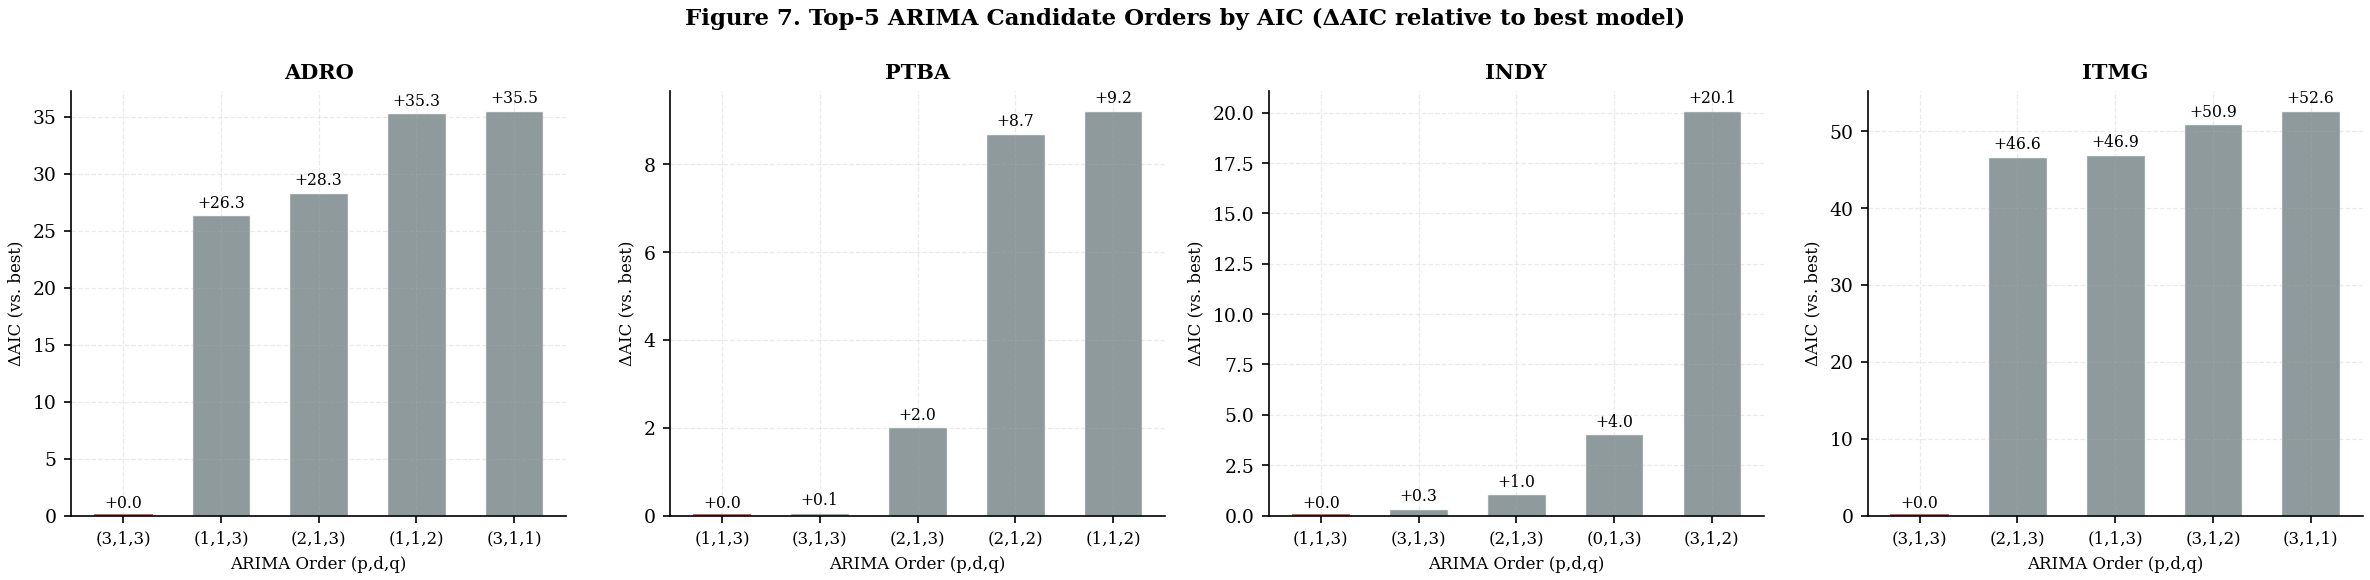

✓  fig07_arima_grid_aic.png


In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)

for ax, ticker, warna in zip(axes, ticker_list, warna_saham):
    top5 = grid_results[ticker].head(5).copy()
    top5["label"] = top5.apply(lambda r: f"({int(r.p)},{int(r.d)},{int(r.q)})", axis=1)
    # AIC relatif supaya bar tidak terlalu kecil bedanya
    top5["ΔAIC"]  = top5["AIC"] - top5["AIC"].min()

    bars = ax.bar(
        top5["label"],
        top5["ΔAIC"],
        color=[warna if i==0 else C["gray"] for i in range(len(top5))],
        edgecolor="white",
        linewidth=0.7,
        alpha=0.88,
        width=0.6
    )
    ax.bar_label(bars, labels=[f"+{v:.1f}" for v in top5["ΔAIC"]],
                 fontsize=7.5, padding=2)
    ax.set_title(f"{ticker}", fontweight="bold", fontsize=10)
    ax.set_xlabel("ARIMA Order (p,d,q)", fontsize=8)
    ax.set_ylabel("ΔAIC (vs. best)", fontsize=8)
    ax.tick_params(axis="x", labelsize=8)
    # Tandai best
    ax.get_children()[0].set_edgecolor(C["red"])
    ax.get_children()[0].set_linewidth(1.8)

fig.suptitle(
    "Figure 7. Top-5 ARIMA Candidate Orders by AIC (ΔAIC relative to best model)",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
fig.savefig(f"{DIR_FIG}/fig07_arima_grid_aic.png", dpi=300)
plt.show()
print("✓  fig07_arima_grid_aic.png")

## 7. Tabel 3 — Orde ARIMA Terpilih per Emiten

In [13]:
rows = []
for ticker in ticker_list:
    top  = grid_results[ticker].head(5)
    best = top.iloc[0]
    rows.append({
        "Emiten":       ticker,
        "Best (p,d,q)": f"({int(best.p)},{int(best.d)},{int(best.q)})",
        "AIC":          best.AIC,
        "BIC":          best.BIC,
        "HQIC":         best.HQIC,
        "LogL":         best.LogL,
        "2nd Candidate":f"({int(top.iloc[1].p)},{int(top.iloc[1].d)},{int(top.iloc[1].q)}) AIC={top.iloc[1].AIC:.2f}",
        "3rd Candidate":f"({int(top.iloc[2].p)},{int(top.iloc[2].d)},{int(top.iloc[2].q)}) AIC={top.iloc[2].AIC:.2f}",
    })

tbl3 = pd.DataFrame(rows)
tbl3.to_csv(f"{DIR_DATA}/tabel03_arima_orders.csv", index=False)
print("✓  tabel03_arima_orders.csv")
tbl3

✓  tabel03_arima_orders.csv


,Emiten,"Best (p,d,q)",AIC,BIC,HQIC,LogL,2nd Candidate,3rd Candidate
0,ADRO,"(3,1,3)",23369.49,23409.80,23384.17,-11677.74,"(1,1,3) AIC=23395.83","(2,1,3) AIC=23397.77"
1,PTBA,"(1,1,3)",27575.10,27603.89,27585.59,-13782.55,"(3,1,3) AIC=27575.17","(2,1,3) AIC=27577.11"
2,INDY,"(1,1,3)",41759.65,41788.44,41770.14,-20874.82,"(3,1,3) AIC=41759.99","(2,1,3) AIC=41760.70"
3,ITMG,"(3,1,3)",7461.33,7501.64,7476.01,-3723.66,"(2,1,3) AIC=7507.96","(1,1,3) AIC=7508.21"


## 8. Fitting Model ARIMA Terbaik per Emiten

Setelah orde optimal dipilih via AIC, model di-*fit* pada **seluruh data train**.
Summary model dicetak untuk dokumentasi jurnal.


In [14]:
fitted_models    = {}
arima_fitted_val = {}   # in-sample fitted values
arima_residuals  = {}   # residual → feed ke LSTM
arima_aic_bic    = {}

for ticker in ticker_list:
    p, d, q = best_orders[ticker]
    seri     = df_train[ticker].dropna()

    mdl = SARIMAX(
        seri,
        order=(p, d, q),
        trend="n",
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False, method="lbfgs", maxiter=500)

    fitted_models[ticker]    = mdl
    arima_fitted_val[ticker] = mdl.fittedvalues
    arima_residuals[ticker]  = mdl.resid
    arima_aic_bic[ticker]    = {"AIC": mdl.aic, "BIC": mdl.bic}

    print(f"\n{'='*55}")
    print(f"  {ticker}  ARIMA{best_orders[ticker]}")
    print(f"  AIC={mdl.aic:.2f}  BIC={mdl.bic:.2f}  σ²={mdl.params[-1] if hasattr(mdl,'params') else 'n/a'}")
    print(f"  Obs={len(seri):,}")


  ADRO  ARIMA(3, 1, 3)
  AIC=23369.49  BIC=23409.80  σ²=1251.9535898088413
  Obs=2,347

  PTBA  ARIMA(1, 1, 3)
  AIC=27575.10  BIC=27603.89  σ²=7615.437162994037
  Obs=2,347

  INDY  ARIMA(1, 1, 3)
  AIC=41759.65  BIC=41788.44  σ²=3243767.216427774
  Obs=2,347

  ITMG  ARIMA(3, 1, 3)
  AIC=7461.33  BIC=7501.64  σ²=1.3985494880370646
  Obs=2,347


## 9. Diagnostik Residual ARIMA (Figure 8)

Panel diagnostik standar:
- (a) Time plot residual
- (b) Distribusi residual + KDE + Normal fit
- (c) Q-Q Plot
- (d) ACF residual — uji white noise
- (e) PACF residual
- (f) Ljung-Box p-values (10–40 lag)

Jika residual berperilaku white noise → komponen linear sudah tertangkap ARIMA,
sisa non-linear ditangkap oleh LSTM.


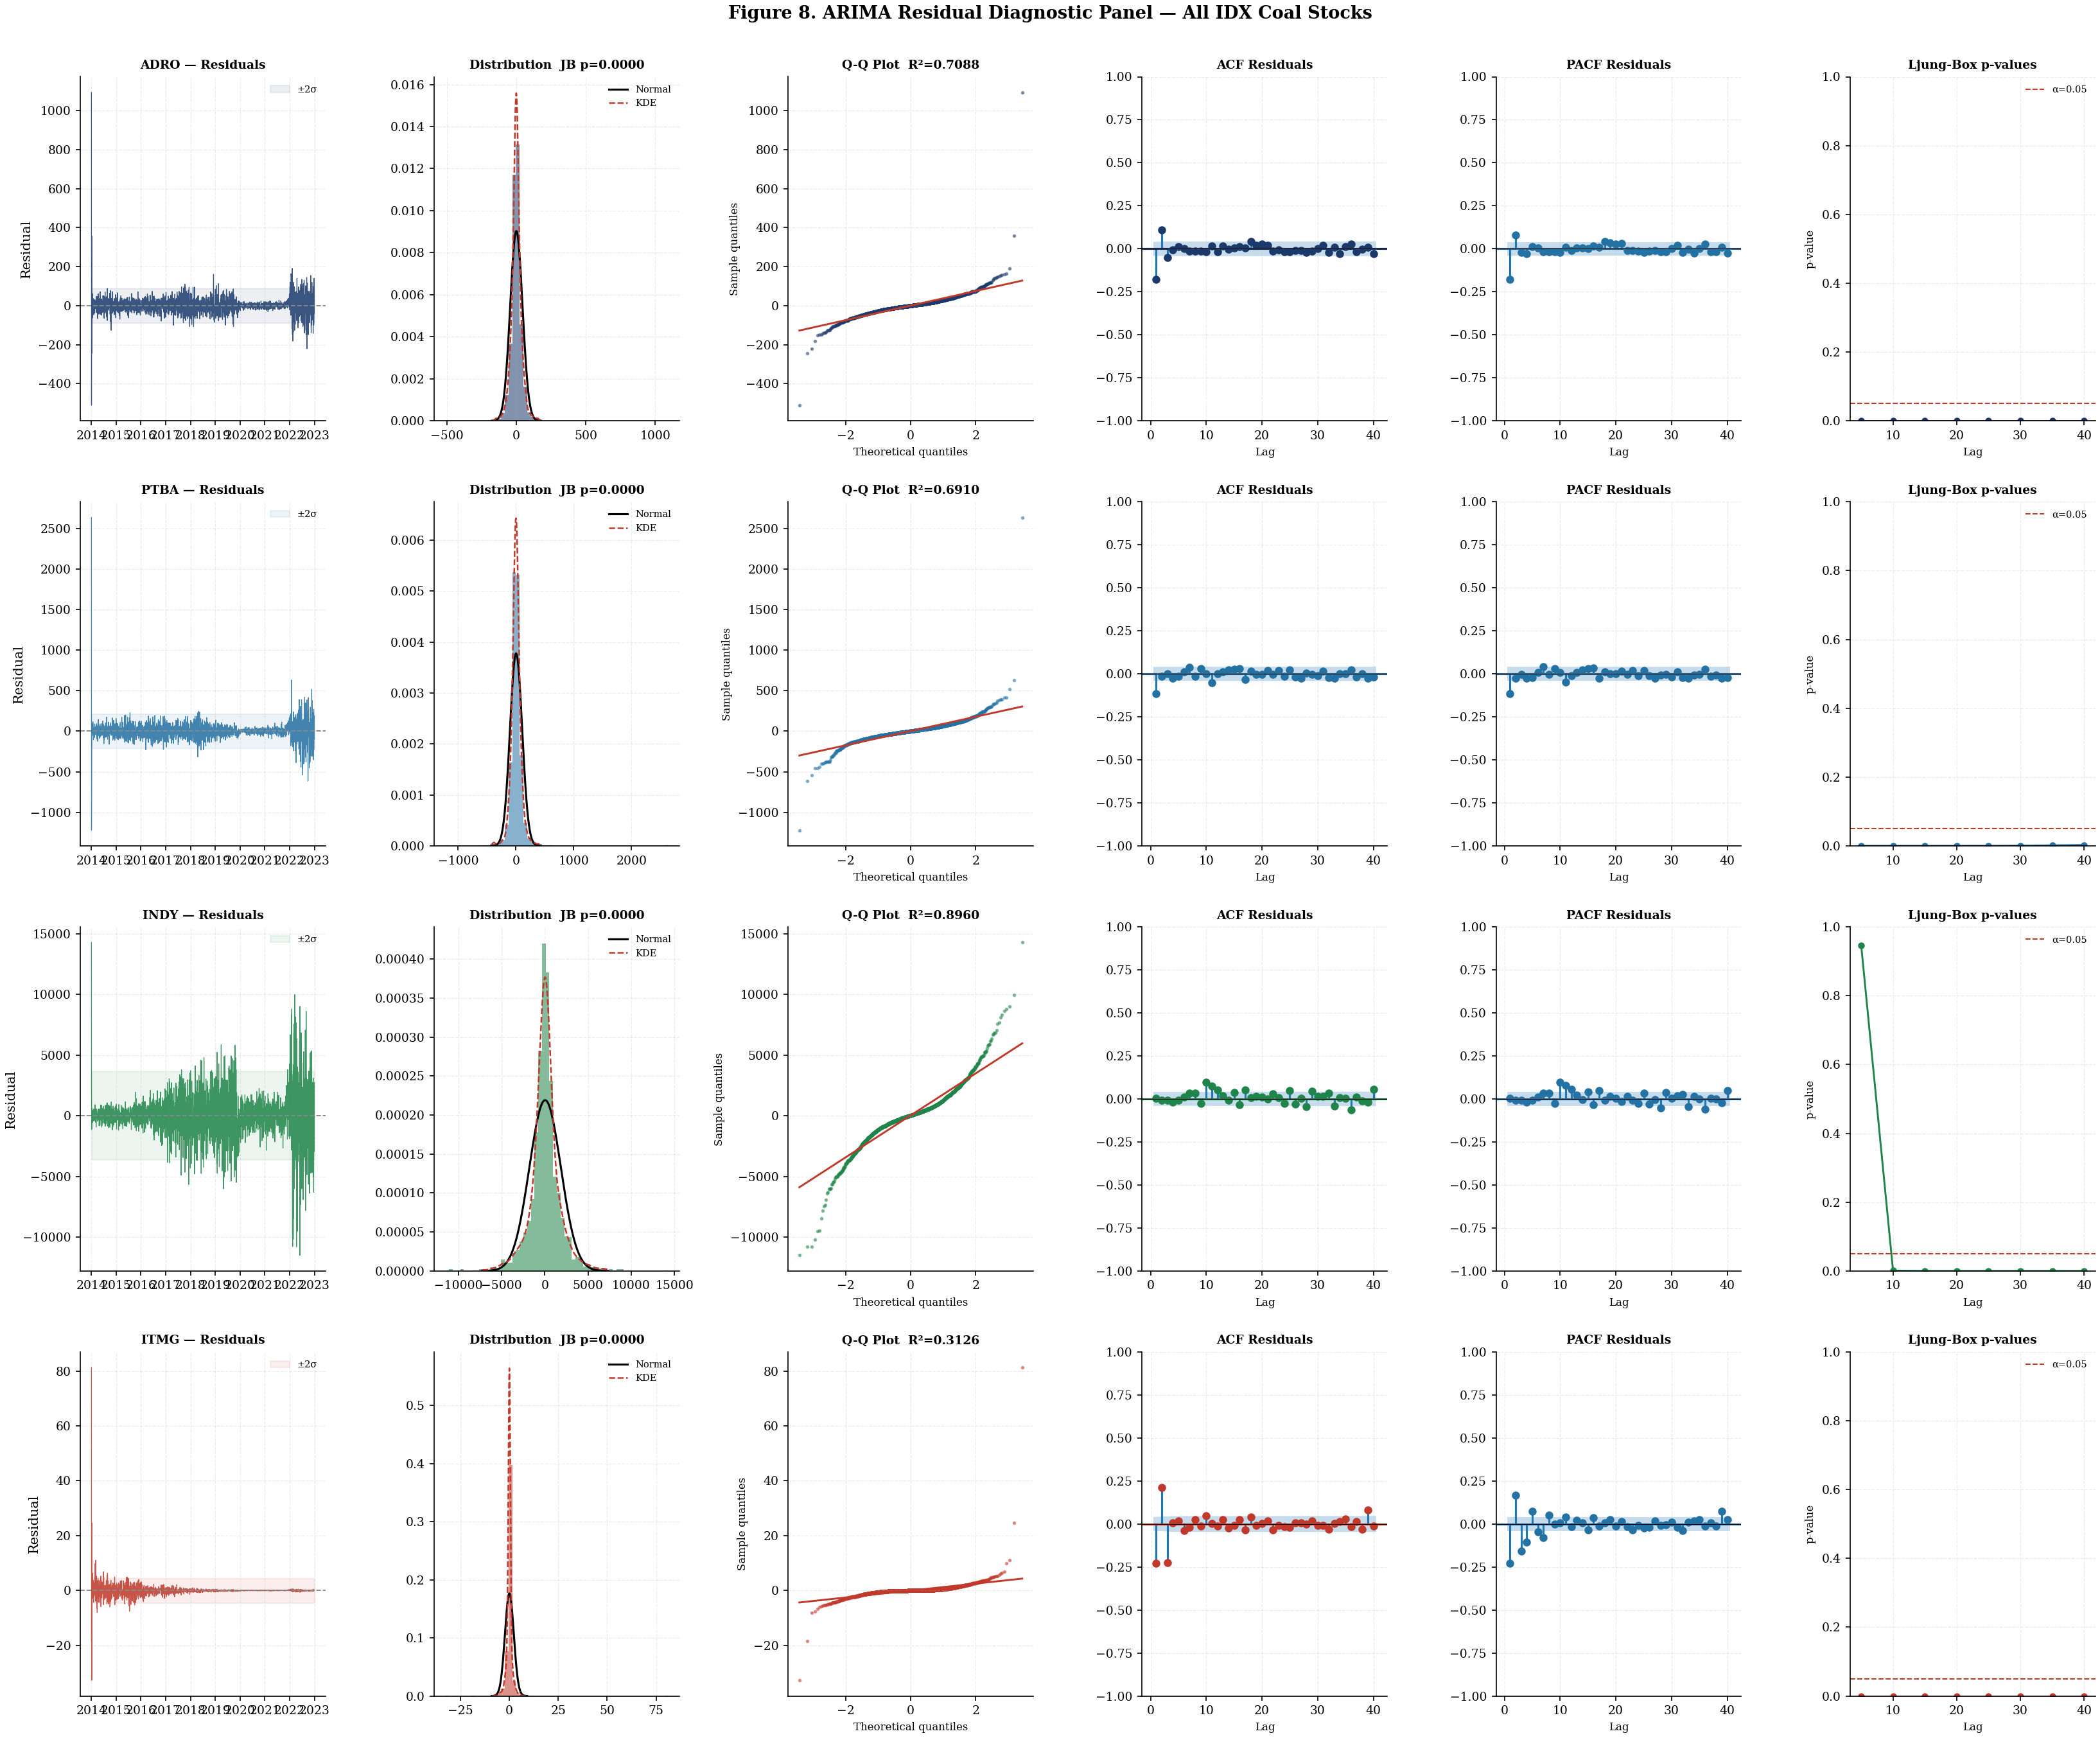

✓  fig08_arima_residual_diagnostics.png


In [15]:
fig, axes_all = plt.subplots(
    len(ticker_list), 6,
    figsize=(22, 4.5 * len(ticker_list))
)

for row, (ticker, warna) in enumerate(zip(ticker_list, warna_saham)):
    resid = arima_residuals[ticker].dropna()
    axes  = axes_all[row]

    # ── (a) Residual time plot ────────────────────────────────────────
    axes[0].plot(resid.index, resid, color=warna, lw=0.6, alpha=0.85)
    axes[0].axhline(0, color=C["gray"], lw=0.9, ls="--")
    axes[0].fill_between(
        resid.index,
        resid.mean() - 2*resid.std(),
        resid.mean() + 2*resid.std(),
        alpha=0.08, color=warna, label="±2σ"
    )
    axes[0].set_title(f"{ticker} — Residuals", fontweight="bold", fontsize=9)
    axes[0].set_ylabel("Residual")
    axes[0].legend(frameon=False, fontsize=7)

    # ── (b) Histogram + KDE + Normal ─────────────────────────────────
    mu_r, std_r = resid.mean(), resid.std()
    axes[1].hist(resid, bins=60, color=warna, alpha=0.55,
                 density=True, edgecolor="none")
    x_fit = np.linspace(mu_r - 4*std_r, mu_r + 4*std_r, 300)
    axes[1].plot(x_fit, stats.norm.pdf(x_fit, mu_r, std_r),
                 color="black", lw=1.5, label="Normal")
    axes[1].plot(x_fit, stats.gaussian_kde(resid)(x_fit),
                 color=C["red"], lw=1.2, ls="--", label="KDE")
    jb_s, jb_p = jarque_bera(resid)
    axes[1].set_title(f"Distribution  JB p={jb_p:.4f}", fontweight="bold", fontsize=9)
    axes[1].legend(frameon=False, fontsize=7)

    # ── (c) Q-Q Plot ─────────────────────────────────────────────────
    (osm, osr), (slope, intercept, r_val) = stats.probplot(resid, dist="norm")
    axes[2].scatter(osm, osr, s=3, color=warna, alpha=0.45)
    x_line = np.array([min(osm), max(osm)])
    axes[2].plot(x_line, slope*x_line + intercept, color=C["red"], lw=1.4)
    axes[2].set_title(f"Q-Q Plot  R²={r_val**2:.4f}", fontweight="bold", fontsize=9)
    axes[2].set_xlabel("Theoretical quantiles", fontsize=8)
    axes[2].set_ylabel("Sample quantiles", fontsize=8)

    # ── (d) ACF residual ─────────────────────────────────────────────
    plot_acf(resid, ax=axes[3], lags=40,
             color=warna, alpha=0.05, zero=False)
    axes[3].set_title("ACF Residuals", fontweight="bold", fontsize=9)
    axes[3].axhline(0, color="black", lw=0.5)
    axes[3].set_xlabel("Lag", fontsize=8)

    # ── (e) PACF residual ────────────────────────────────────────────
    plot_pacf(resid, ax=axes[4], lags=40,
              color=C["blue"], alpha=0.05, zero=False, method="ywm")
    axes[4].set_title("PACF Residuals", fontweight="bold", fontsize=9)
    axes[4].axhline(0, color="black", lw=0.5)
    axes[4].set_xlabel("Lag", fontsize=8)

    # ── (f) Ljung-Box p-values ────────────────────────────────────────
    lags_lb = list(range(5, 45, 5))
    lb_res  = acorr_ljungbox(resid, lags=lags_lb, return_df=True)
    axes[5].plot(lags_lb, lb_res["lb_pvalue"].values,
                 color=warna, lw=1.4, marker="o", ms=4)
    axes[5].axhline(0.05, color=C["red"], lw=1.0, ls="--", label="α=0.05")
    axes[5].set_ylim(0, 1)
    axes[5].set_title("Ljung-Box p-values", fontweight="bold", fontsize=9)
    axes[5].set_xlabel("Lag", fontsize=8)
    axes[5].set_ylabel("p-value", fontsize=8)
    axes[5].legend(frameon=False, fontsize=7)

fig.suptitle(
    "Figure 8. ARIMA Residual Diagnostic Panel — All IDX Coal Stocks",
    fontsize=13, fontweight="bold", y=1.005
)
plt.tight_layout(h_pad=2.0, w_pad=1.5)
fig.savefig(f"{DIR_FIG}/fig08_arima_residual_diagnostics.png", dpi=300)
plt.show()
print("✓  fig08_arima_residual_diagnostics.png")

## 10. Fitted Values vs Aktual — In-Sample (Figure 9)

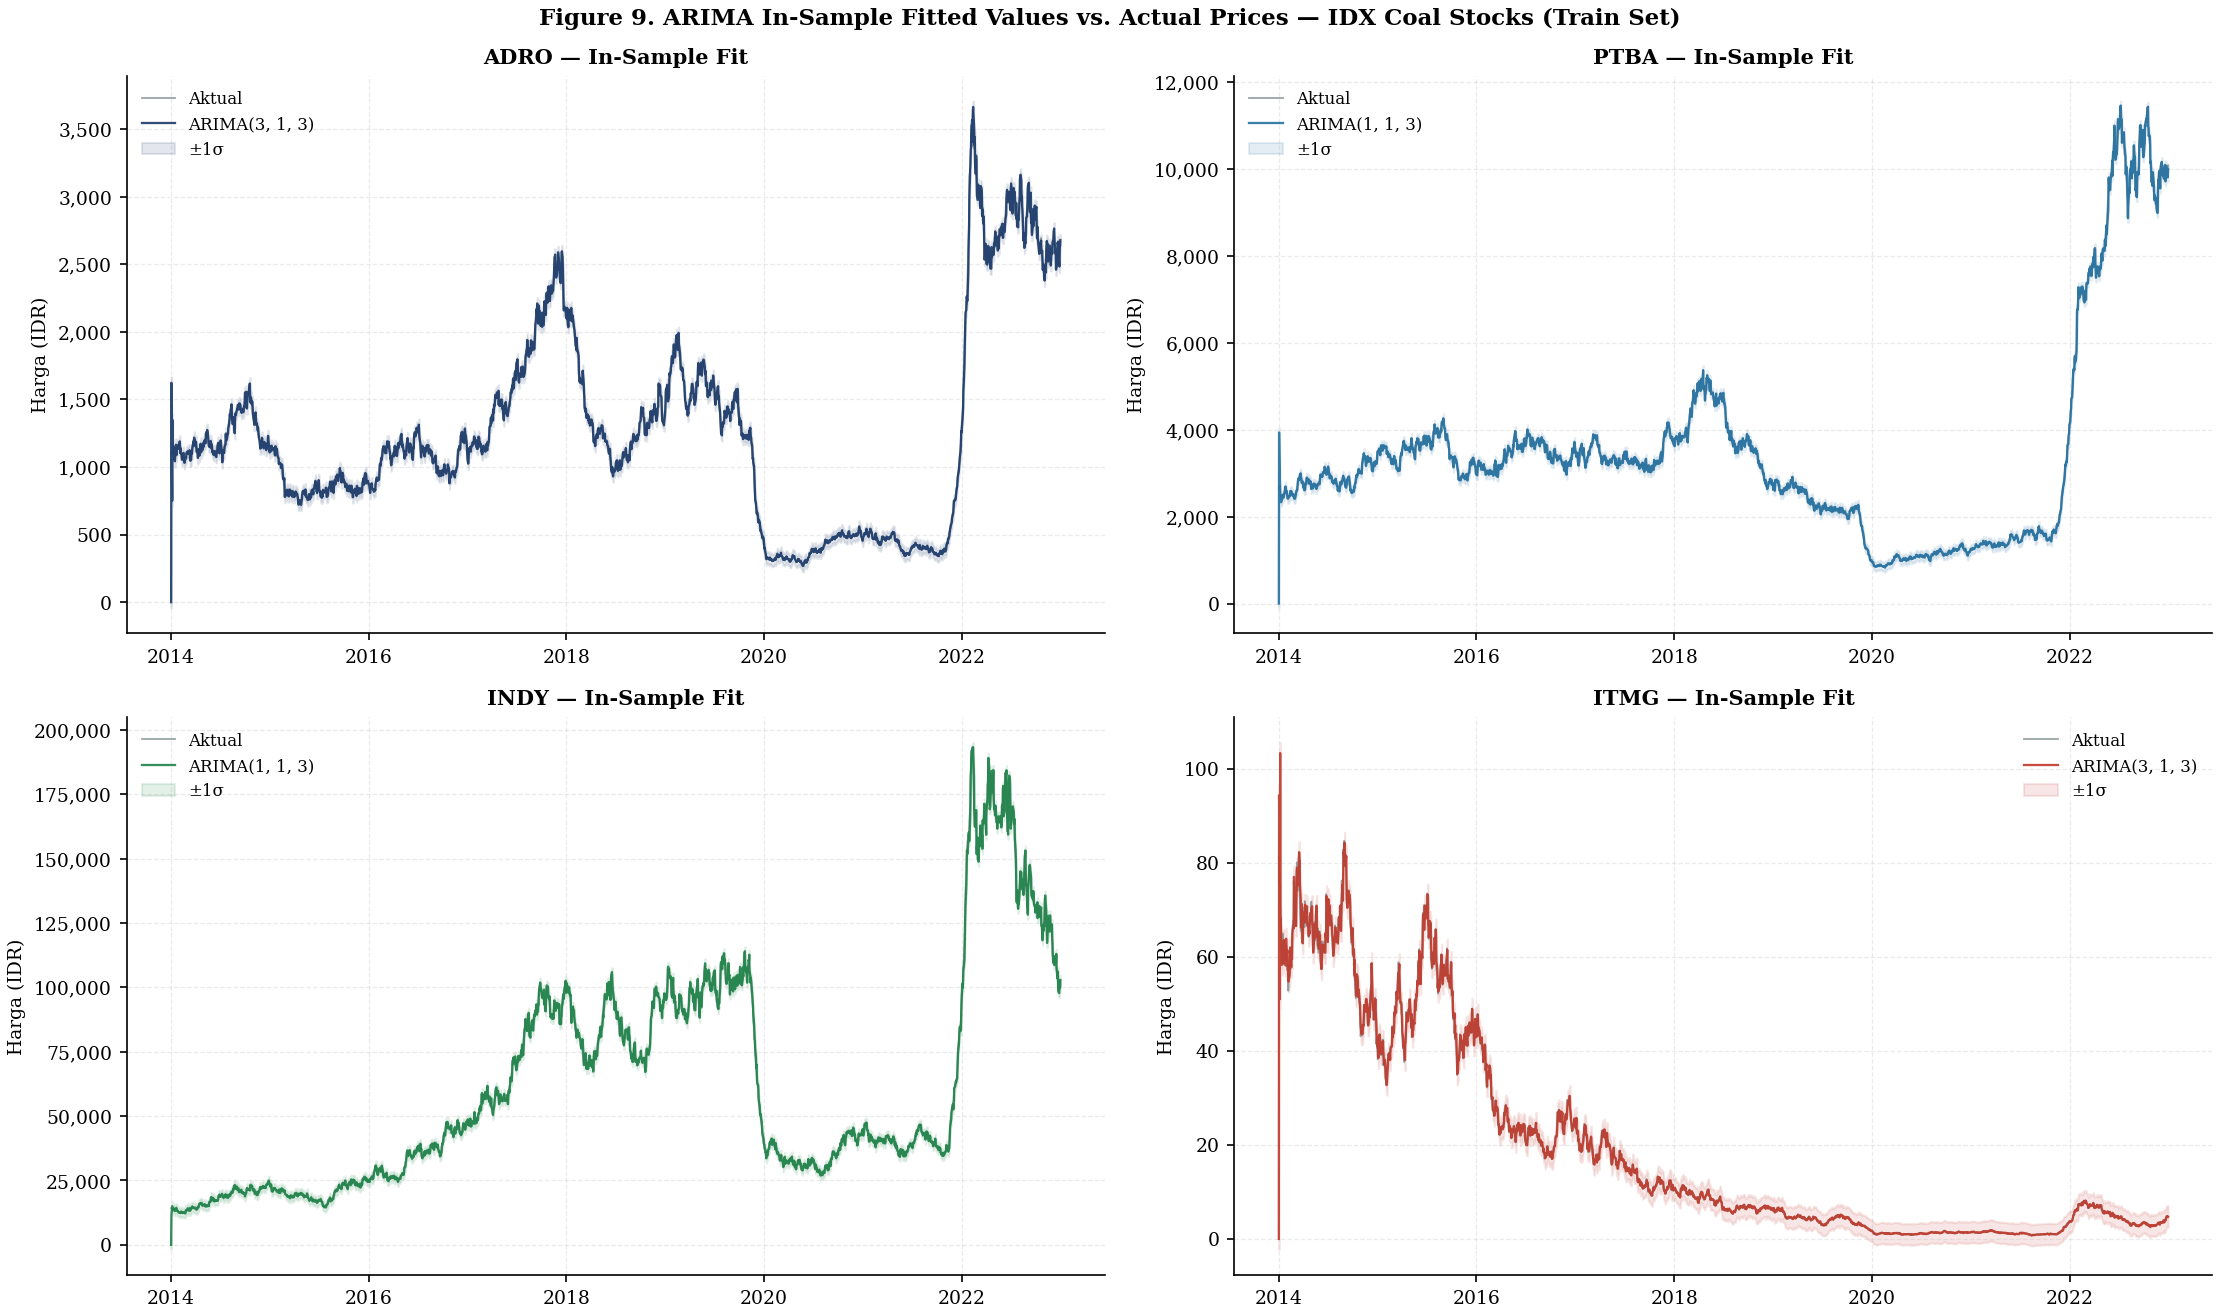

✓  fig09_arima_insample_fit.png


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

for ax, ticker, warna in zip(axes, ticker_list, warna_saham):
    aktual = df_train[ticker]
    fitted = arima_fitted_val[ticker]

    ax.plot(aktual.index, aktual,
            color=C["gray"], lw=0.85, alpha=0.8, label="Aktual")
    ax.plot(fitted.index, fitted,
            color=warna, lw=1.1, alpha=0.9, label=f"ARIMA{best_orders[ticker]}")

    # Error band
    resid = aktual - fitted
    ax.fill_between(
        fitted.index,
        fitted - resid.std(),
        fitted + resid.std(),
        alpha=0.12, color=warna, label="±1σ"
    )
    ax.set_title(f"{ticker} — In-Sample Fit", fontweight="bold", fontsize=10)
    ax.set_ylabel("Harga (IDR)", fontsize=9)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.legend(frameon=False, fontsize=8)

fig.suptitle(
    "Figure 9. ARIMA In-Sample Fitted Values vs. Actual Prices — IDX Coal Stocks (Train Set)",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
fig.savefig(f"{DIR_FIG}/fig09_arima_insample_fit.png", dpi=300)
plt.show()
print("✓  fig09_arima_insample_fit.png")

## 11. Out-of-Sample Forecast — Test Set (Figure 10)

Model di-*refit* secara rolling satu langkah (*1-step ahead rolling forecast*)
pada test set untuk evaluasi yang tidak bias.


In [17]:
def rolling_forecast_arima(train_series, test_series, order):
    """
    1-step ahead rolling forecast:
    model diupdate setiap hari dengan menambahkan observasi aktual.
    Lebih realistis dibanding multi-step langsung.
    """
    history   = list(train_series)
    forecasts = []
    for t in range(len(test_series)):
        mdl  = SARIMAX(
            history, order=order, trend="n",
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False, method="lbfgs", maxiter=200)
        fc   = mdl.forecast(steps=1)[0]
        forecasts.append(fc)
        history.append(test_series.iloc[t])
    return np.array(forecasts)


print("Rolling forecast sedang berjalan (sekali per emiten) ...")
arima_forecast = {}
for ticker in ticker_list:
    print(f"  → {ticker} ...", end=" ", flush=True)
    fc = rolling_forecast_arima(
        df_train[ticker].dropna(),
        df_test[ticker],
        best_orders[ticker]
    )
    arima_forecast[ticker] = pd.Series(fc, index=df_test.index[:len(fc)])
    print("selesai")

print("\nSemua forecast selesai.")

Rolling forecast sedang berjalan (sekali per emiten) ...
  → ADRO ... selesai
  → PTBA ... selesai
  → INDY ... selesai
  → ITMG ... selesai

Semua forecast selesai.


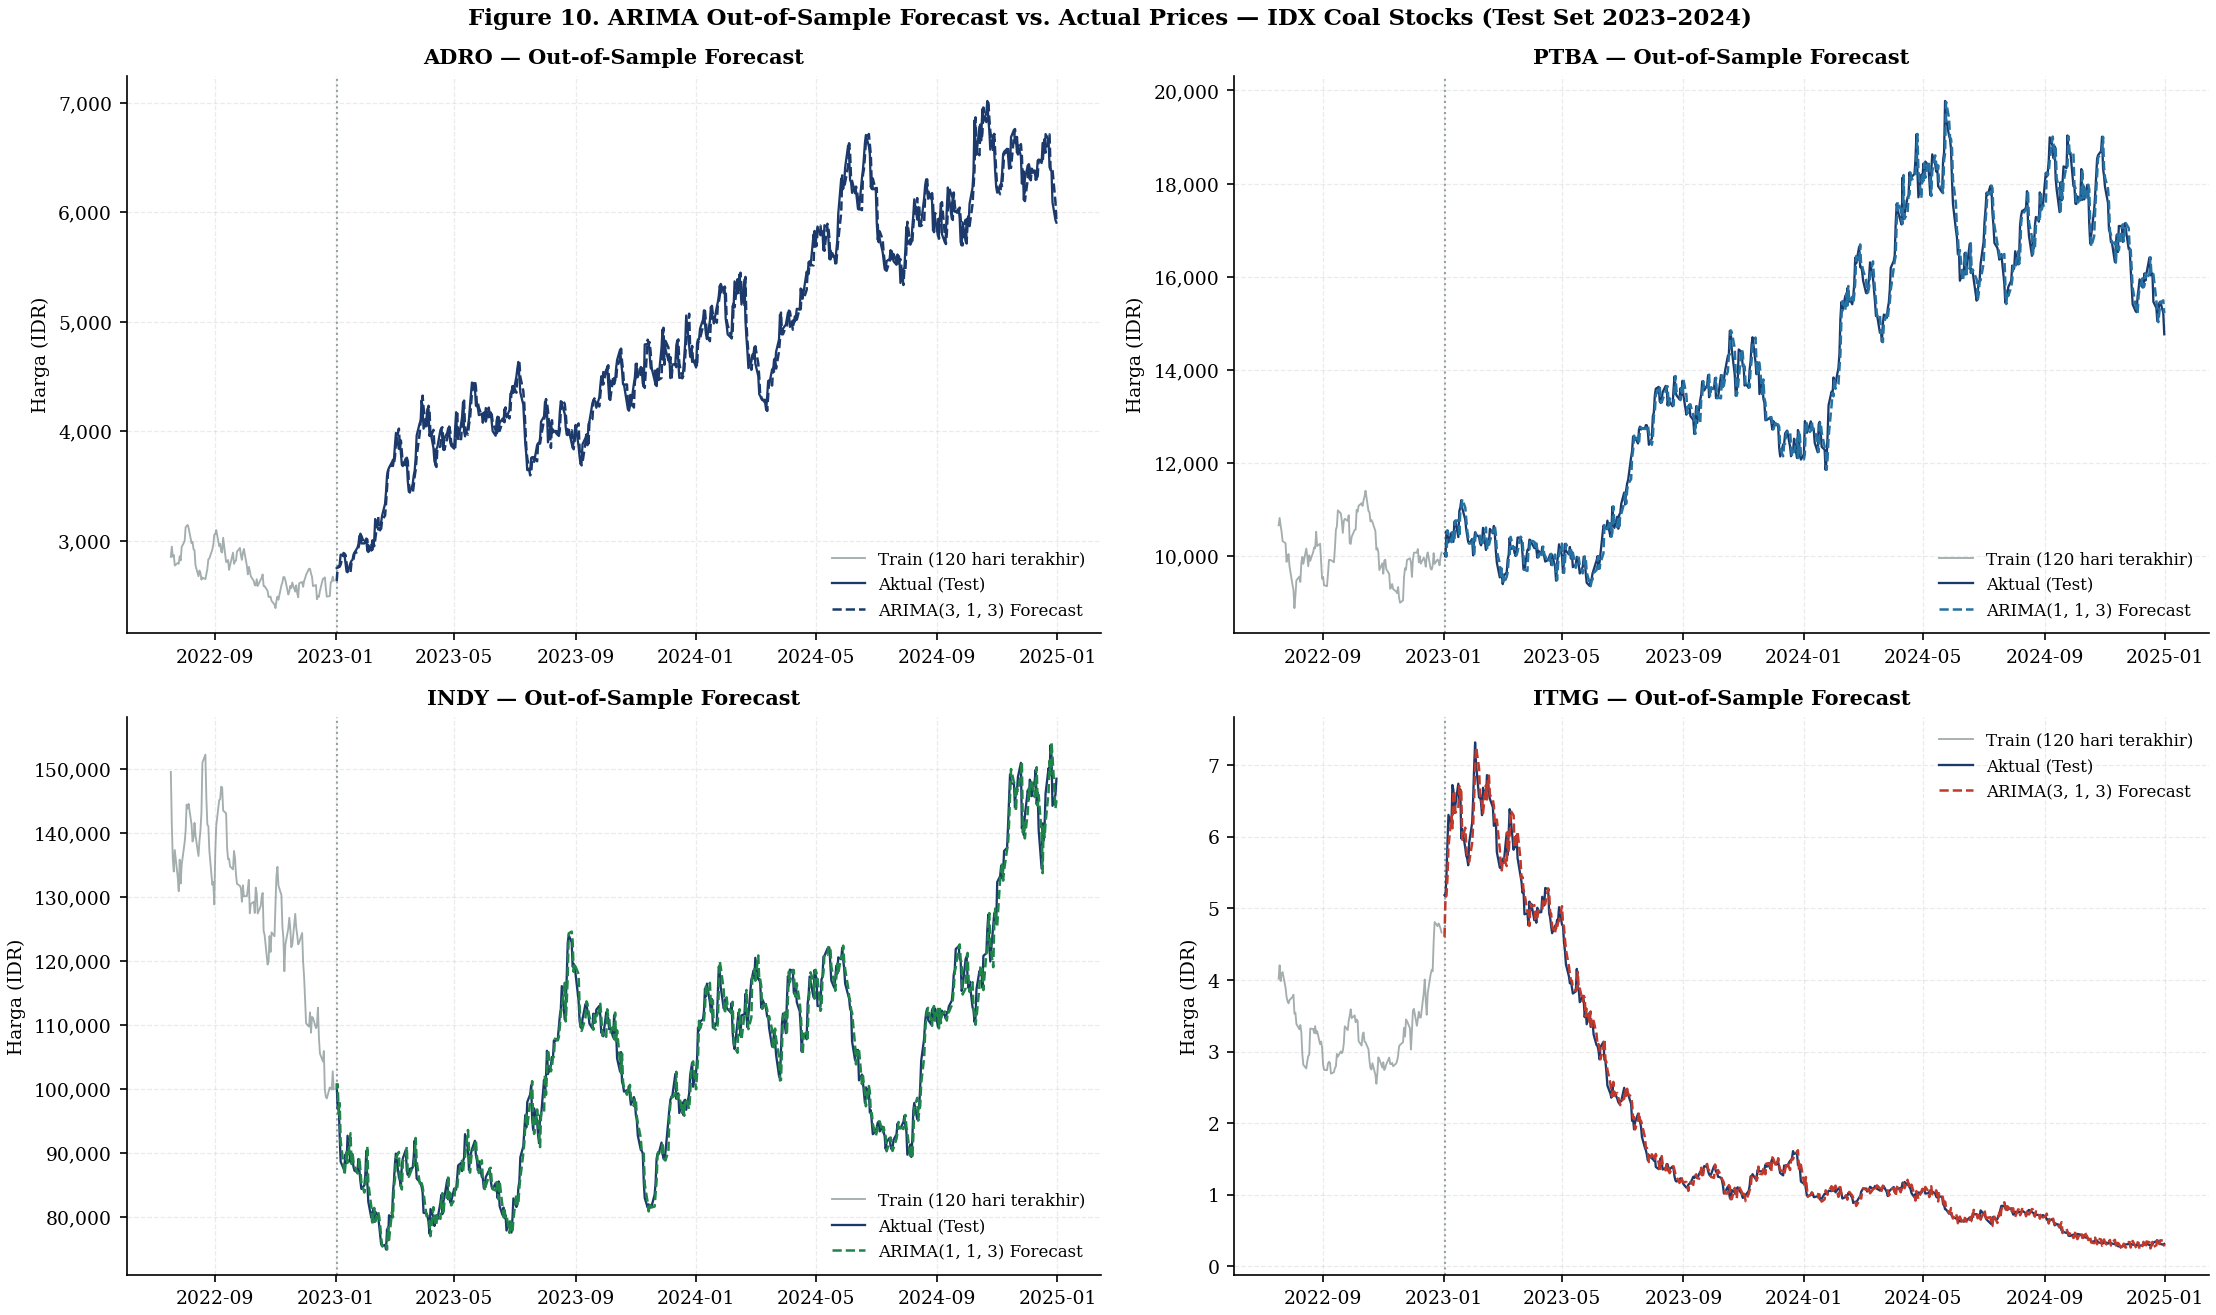

✓  fig10_arima_forecast_test.png


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

for ax, ticker, warna in zip(axes, ticker_list, warna_saham):
    aktual_test = df_test[ticker]
    fc_series   = arima_forecast[ticker]

    ax.plot(df_train[ticker].index[-120:],
            df_train[ticker].iloc[-120:],
            color=C["gray"], lw=0.9, alpha=0.7, label="Train (120 hari terakhir)")
    ax.axvline(df_test.index[0], color=C["gray"],
               lw=1.0, ls=":", alpha=0.8)
    ax.plot(aktual_test.index, aktual_test,
            color=C["navy"], lw=1.1, label="Aktual (Test)")
    ax.plot(fc_series.index, fc_series,
            color=warna, lw=1.2, ls="--",
            label=f"ARIMA{best_orders[ticker]} Forecast")

    ax.set_title(f"{ticker} — Out-of-Sample Forecast",
                 fontweight="bold", fontsize=10)
    ax.set_ylabel("Harga (IDR)", fontsize=9)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    ax.legend(frameon=False, fontsize=8)

fig.suptitle(
    "Figure 10. ARIMA Out-of-Sample Forecast vs. Actual Prices — IDX Coal Stocks (Test Set 2023–2024)",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
fig.savefig(f"{DIR_FIG}/fig10_arima_forecast_test.png", dpi=300)
plt.show()
print("✓  fig10_arima_forecast_test.png")

## 12. Evaluasi Metrik ARIMA (Tabel 4)

Metrik evaluasi standar forecasting:
| Metrik | Formula | Interpretasi |
|--------|---------|-------------|
| MAE    | (1/n)Σ\|yₜ−ŷₜ\| | Error rata-rata absolut |
| RMSE   | √((1/n)Σ(yₜ−ŷₜ)²) | Sensitif terhadap outlier |
| MAPE   | (100/n)Σ\|yₜ−ŷₜ\|/yₜ | Error relatif (%) |
| R²     | 1 − SS_res/SS_tot | Goodness of fit |


In [19]:
def hitung_metrik(aktual, prediksi, label="Model"):
    mae  = mean_absolute_error(aktual, prediksi)
    rmse = np.sqrt(mean_squared_error(aktual, prediksi))
    mape = np.mean(np.abs((aktual - prediksi) / aktual)) * 100
    r2   = r2_score(aktual, prediksi)
    return {
        "Model": label,
        "MAE":   round(mae,  4),
        "RMSE":  round(rmse, 4),
        "MAPE (%)": round(mape, 4),
        "R²":    round(r2,   6),
    }


arima_metrics = {}
rows_eval = []

for ticker in ticker_list:
    aktual = df_test[ticker].values
    fc     = arima_forecast[ticker].values
    m      = hitung_metrik(aktual, fc, label=f"ARIMA{best_orders[ticker]}")
    m["Emiten"] = ticker
    arima_metrics[ticker] = m
    rows_eval.append(m)

tbl4 = pd.DataFrame(rows_eval)[["Emiten","Model","MAE","RMSE","MAPE (%)","R²"]]
tbl4.to_csv(f"{DIR_DATA}/tabel04_arima_metrics.csv", index=False)
print("✓  tabel04_arima_metrics.csv")
tbl4

✓  tabel04_arima_metrics.csv


,Emiten,Model,MAE,RMSE,MAPE (%),R²
0,ADRO,"ARIMA(3, 1, 3)",95.9907,121.4728,1.9719,0.986775
1,PTBA,"ARIMA(1, 1, 3)",239.1403,303.2944,1.6923,0.989198
2,INDY,"ARIMA(1, 1, 3)",1907.3301,2420.5386,1.8245,0.981016
3,ITMG,"ARIMA(3, 1, 3)",0.0784,0.1229,5.1763,0.995727


## 13. Distribusi Error & Scatter Aktual vs Prediksi (Figure 11)

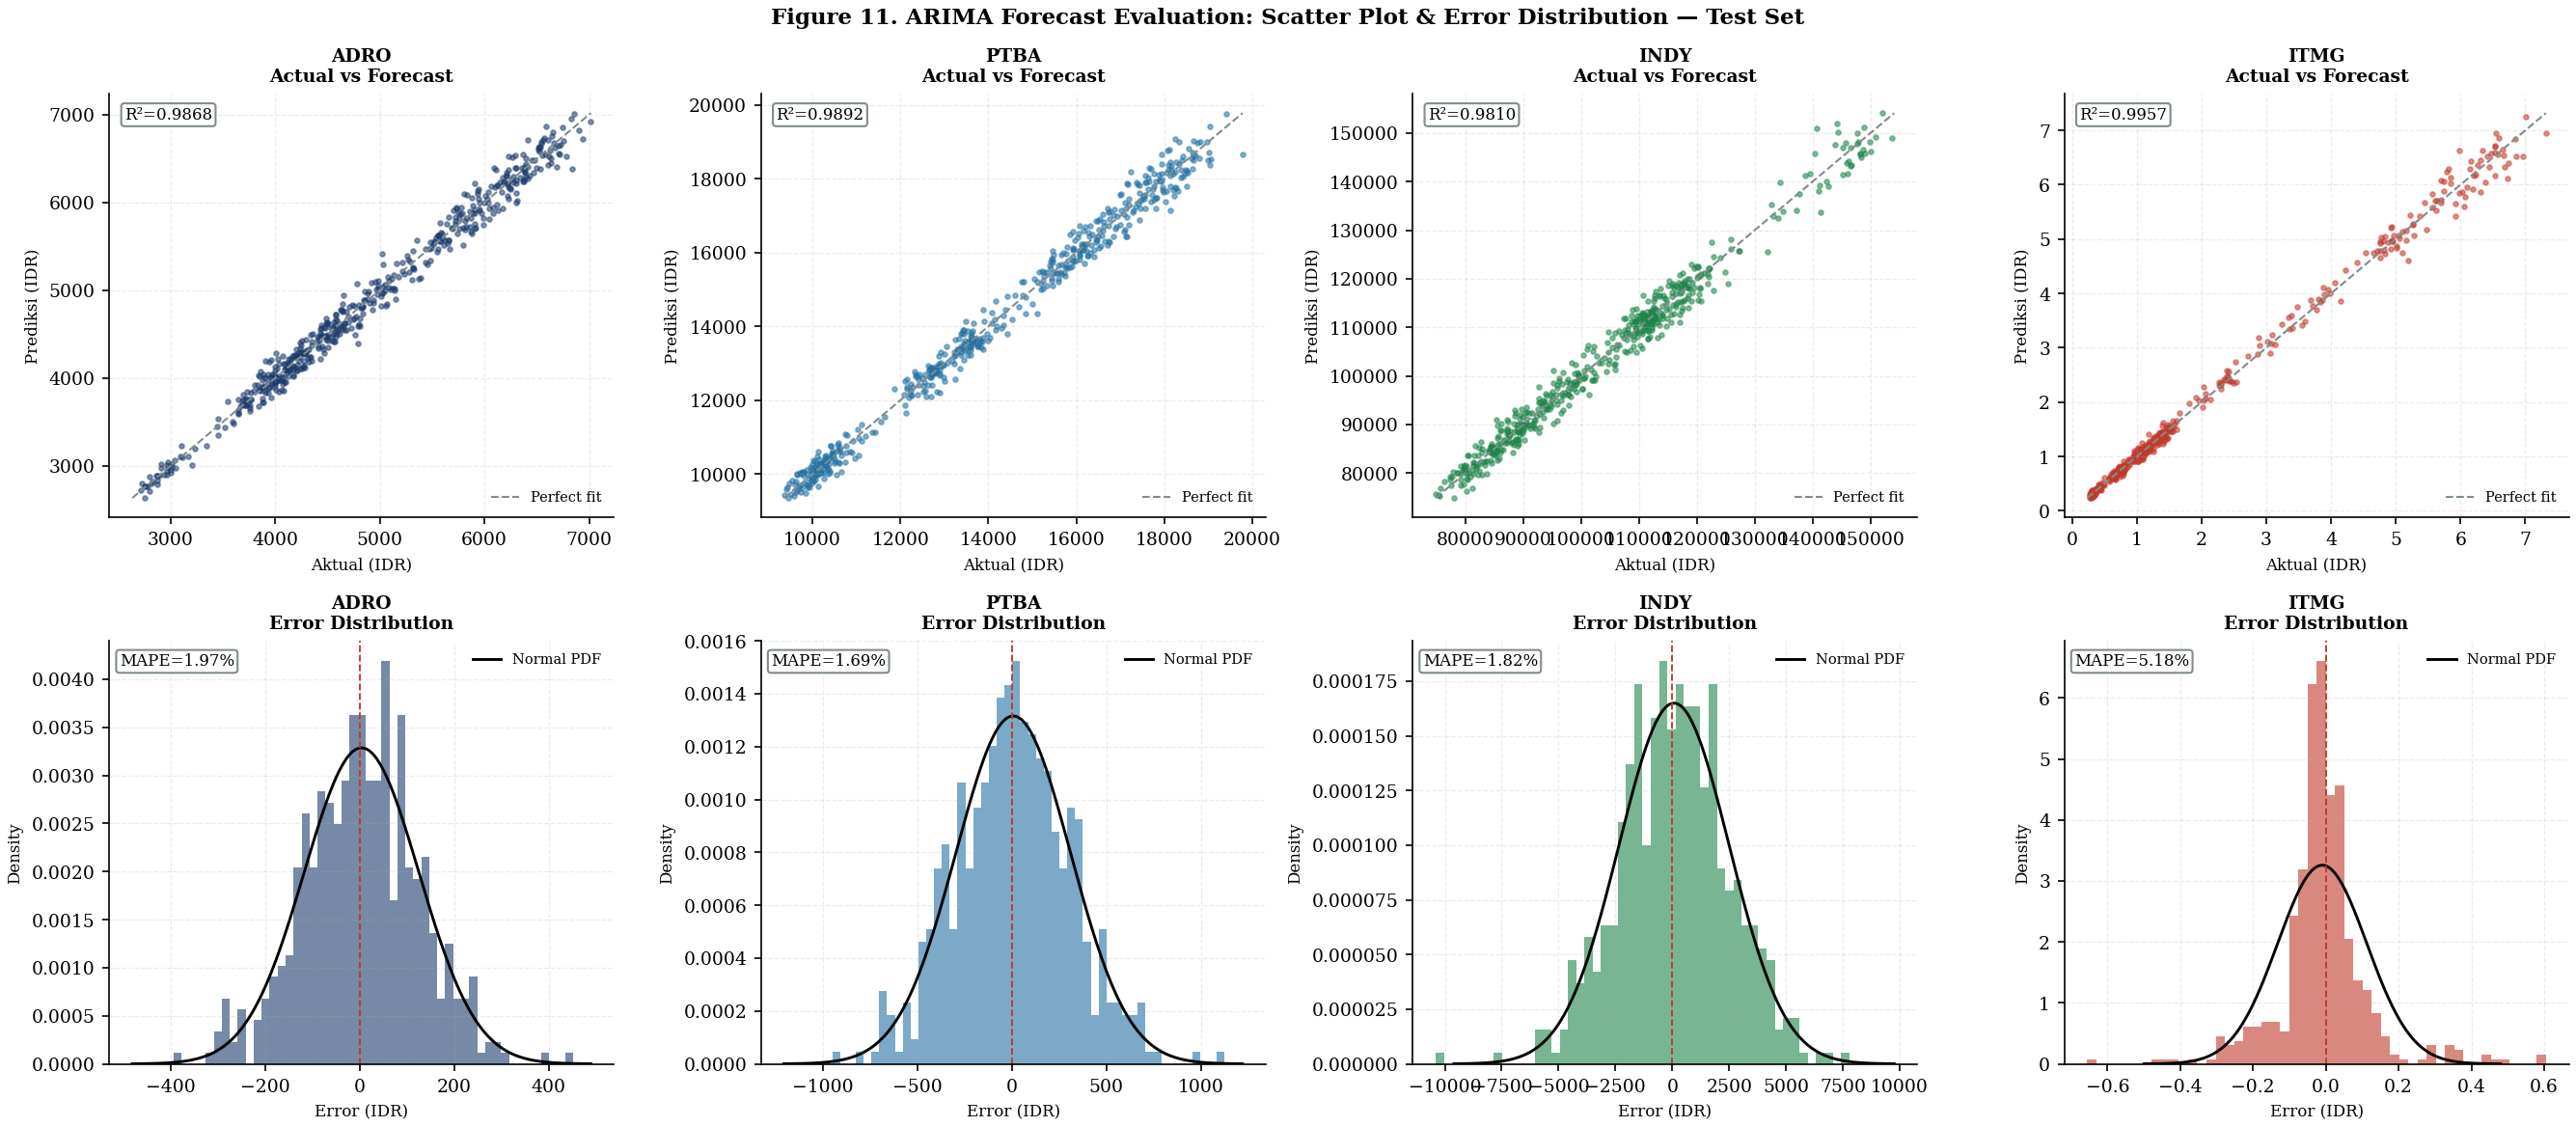

✓  fig11_arima_error_analysis.png


In [20]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for col, (ticker, warna) in enumerate(zip(ticker_list, warna_saham)):
    aktual = df_test[ticker].values
    fc     = arima_forecast[ticker].values
    err    = aktual - fc

    # ── Baris atas: scatter aktual vs prediksi ────────────────────────
    ax_sc = axes[0, col]
    ax_sc.scatter(aktual, fc, s=5, color=warna, alpha=0.5)
    lims = [min(aktual.min(), fc.min()), max(aktual.max(), fc.max())]
    ax_sc.plot(lims, lims, color=C["gray"], lw=1.0, ls="--", label="Perfect fit")
    ax_sc.set_title(f"{ticker}\nActual vs Forecast", fontweight="bold", fontsize=9)
    ax_sc.set_xlabel("Aktual (IDR)", fontsize=8)
    ax_sc.set_ylabel("Prediksi (IDR)", fontsize=8)
    ax_sc.legend(frameon=False, fontsize=7)
    r2 = r2_score(aktual, fc)
    ax_sc.text(0.03, 0.97, f"R²={r2:.4f}",
               transform=ax_sc.transAxes, fontsize=8, va="top",
               bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=C["gray"]))

    # ── Baris bawah: distribusi error ─────────────────────────────────
    ax_er = axes[1, col]
    ax_er.hist(err, bins=50, color=warna, alpha=0.6, density=True, edgecolor="none")
    mu_e, std_e = err.mean(), err.std()
    x_fit = np.linspace(mu_e-4*std_e, mu_e+4*std_e, 300)
    ax_er.plot(x_fit, stats.norm.pdf(x_fit, mu_e, std_e),
               color="black", lw=1.4, label="Normal PDF")
    ax_er.axvline(0, color=C["red"], lw=0.9, ls="--")
    ax_er.set_title(f"{ticker}\nError Distribution", fontweight="bold", fontsize=9)
    ax_er.set_xlabel("Error (IDR)", fontsize=8)
    ax_er.set_ylabel("Density", fontsize=8)
    mape = np.mean(np.abs(err/aktual))*100
    ax_er.text(0.02, 0.97, f"MAPE={mape:.2f}%",
               transform=ax_er.transAxes, fontsize=8, va="top",
               bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=C["gray"]))
    ax_er.legend(frameon=False, fontsize=7)

fig.suptitle(
    "Figure 11. ARIMA Forecast Evaluation: Scatter Plot & Error Distribution — Test Set",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
fig.savefig(f"{DIR_FIG}/fig11_arima_error_analysis.png", dpi=300)
plt.show()
print("✓  fig11_arima_error_analysis.png")

## 14. Visualisasi Metrik Perbandingan Antar Emiten (Figure 12)

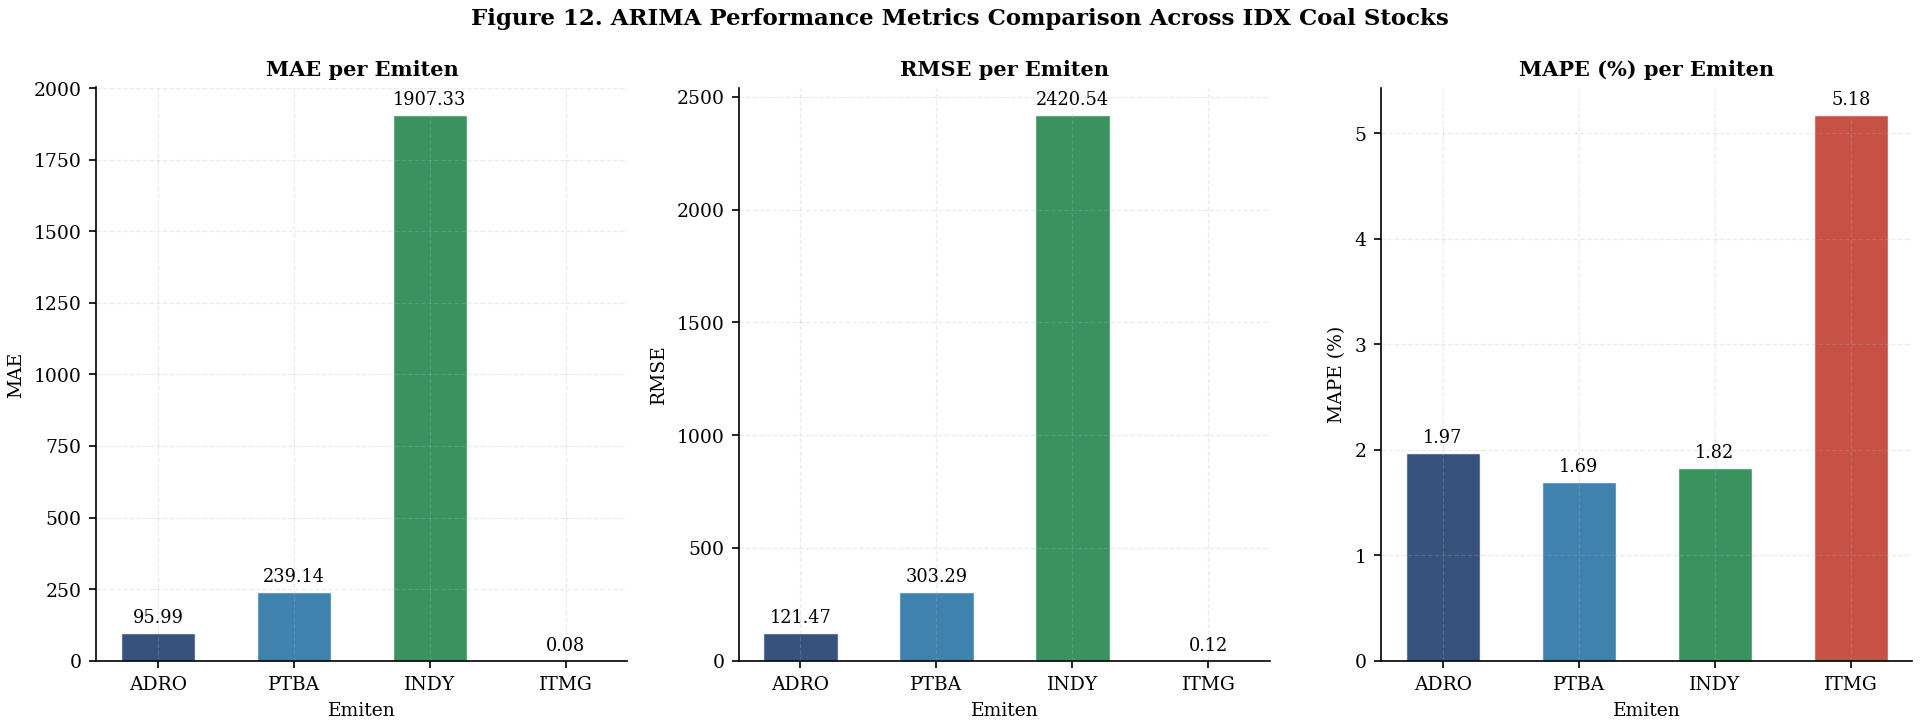

✓  fig12_arima_metrics_bar.png


In [21]:
metrik_cols = ["MAE", "RMSE", "MAPE (%)"]
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

for ax, metrik in zip(axes, metrik_cols):
    vals = [arima_metrics[t][metrik] for t in ticker_list]
    bars = ax.bar(
        ticker_list, vals,
        color=warna_saham,
        edgecolor="white",
        linewidth=0.7,
        width=0.55,
        alpha=0.88
    )
    ax.bar_label(bars, fmt="%.2f", fontsize=8.5, padding=3)
    ax.set_title(f"{metrik} per Emiten", fontweight="bold", fontsize=10)
    ax.set_ylabel(metrik, fontsize=9)
    ax.set_xlabel("Emiten", fontsize=9)

fig.suptitle(
    "Figure 12. ARIMA Performance Metrics Comparison Across IDX Coal Stocks",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
fig.savefig(f"{DIR_FIG}/fig12_arima_metrics_bar.png", dpi=300)
plt.show()
print("✓  fig12_arima_metrics_bar.png")

## 15. Export Residual dan Fitted Values → Input Notebook LSTM

Residual ARIMA yang berisi **komponen non-linear** diekspor ke file pickle.
Notebook `03_model_ann_lstm.ipynb` akan meload file ini sebagai target training LSTM.

Arsitektur hybrid:
```
ŷ_hybrid(t) = ŷ_ARIMA(t)  +  ŷ_LSTM(ε_ARIMA(t))
```
dimana ε_ARIMA(t) = X(t) − ŷ_ARIMA(t)


In [22]:
# Simpan residual (untuk training LSTM)
with open(f"{DIR_DATA}/arima_residuals.pkl", "wb") as f:
    pickle.dump(arima_residuals, f)

# Simpan fitted values (untuk kombinasi hybrid)
with open(f"{DIR_DATA}/arima_fitted.pkl", "wb") as f:
    pickle.dump(arima_fitted_val, f)

# Simpan forecast test set (sebagai baseline perbandingan)
with open(f"{DIR_DATA}/arima_forecast.pkl", "wb") as f:
    pickle.dump(arima_forecast, f)

# Simpan best orders
with open(f"{DIR_DATA}/arima_best_orders.pkl", "wb") as f:
    pickle.dump(best_orders, f)

print("Tersimpan:")
print(f"  {DIR_DATA}/arima_residuals.pkl")
print(f"  {DIR_DATA}/arima_fitted.pkl")
print(f"  {DIR_DATA}/arima_forecast.pkl")
print(f"  {DIR_DATA}/arima_best_orders.pkl")
print()
print("Ringkasan ukuran residual:")
for t, r in arima_residuals.items():
    print(f"  {t}: {len(r):,} observasi  mean={r.mean():.4f}  std={r.std():.4f}")

Tersimpan:
  data/arima_residuals.pkl
  data/arima_fitted.pkl
  data/arima_forecast.pkl
  data/arima_best_orders.pkl

Ringkasan ukuran residual:
  ADRO: 2,347 observasi  mean=0.6162  std=44.1770
  PTBA: 2,347 observasi  mean=2.3782  std=105.6273
  INDY: 2,347 observasi  mean=34.6241  std=1820.7730
  ITMG: 2,347 observasi  mean=-0.0040  std=2.2593


## 16. Rangkuman Hasil ARIMA

In [23]:
print("=" * 60)
print("  RANGKUMAN MODEL ARIMA — JUTIF 2025")
print("=" * 60)
for ticker in ticker_list:
    m = arima_metrics[ticker]
    print(f"  {ticker}  ARIMA{best_orders[ticker]}")
    print(f"    AIC  = {arima_aic_bic[ticker]['AIC']:.2f}")
    print(f"    BIC  = {arima_aic_bic[ticker]['BIC']:.2f}")
    print(f"    MAE  = {m['MAE']:.4f}")
    print(f"    RMSE = {m['RMSE']:.4f}")
    print(f"    MAPE = {m['MAPE (%)']:.4f} %")
    print(f"    R²   = {m['R²']:.6f}")
    print()
print("File output:")
print(f"  figures/ : fig07 – fig12")
print(f"  data/    : tabel03, tabel04, arima_residuals.pkl, arima_fitted.pkl")
print("=" * 60)

  RANGKUMAN MODEL ARIMA — JUTIF 2025
  ADRO  ARIMA(3, 1, 3)
    AIC  = 23369.49
    BIC  = 23409.80
    MAE  = 95.9907
    RMSE = 121.4728
    MAPE = 1.9719 %
    R²   = 0.986775

  PTBA  ARIMA(1, 1, 3)
    AIC  = 27575.10
    BIC  = 27603.89
    MAE  = 239.1403
    RMSE = 303.2944
    MAPE = 1.6923 %
    R²   = 0.989198

  INDY  ARIMA(1, 1, 3)
    AIC  = 41759.65
    BIC  = 41788.44
    MAE  = 1907.3301
    RMSE = 2420.5386
    MAPE = 1.8245 %
    R²   = 0.981016

  ITMG  ARIMA(3, 1, 3)
    AIC  = 7461.33
    BIC  = 7501.64
    MAE  = 0.0784
    RMSE = 0.1229
    MAPE = 5.1763 %
    R²   = 0.995727

File output:
  figures/ : fig07 – fig12
  data/    : tabel03, tabel04, arima_residuals.pkl, arima_fitted.pkl
